In [1]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset Path: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [2]:
import pandas as pd
import numpy as np
import os
import re

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# Check files inside dataset folder

os.listdir(path)

['IMDB Dataset.csv']

In [4]:
file_path = path + "/IMDB Dataset.csv"

df = pd.read_csv(file_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Dataset shape

df.shape

(50000, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [8]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


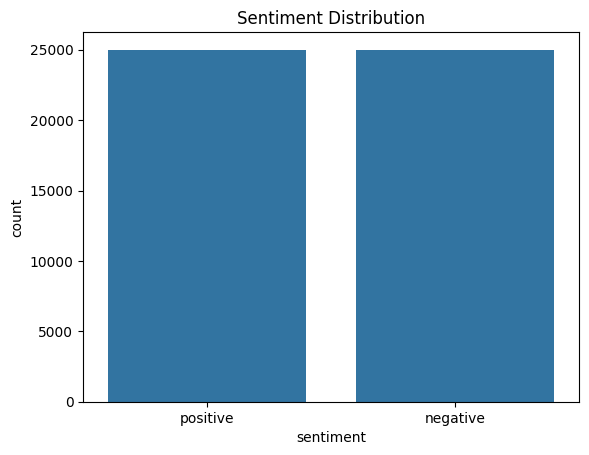

In [9]:
sns.countplot(x=df['sentiment'])

plt.title("Sentiment Distribution")
plt.show()

In [10]:
df['label'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})


df.head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [11]:
stop_words = set(stopwords.words('english'))


def clean_text(text):

    # lowercase
    text = text.lower()

    # remove html tags
    text = re.sub('<.*?>','',text)

    # remove special characters
    text = re.sub('[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub('\s+', ' ', text)

    # remove stopwords
    text = " ".join(
        word for word in text.split()
        if word not in stop_words
    )

    return text

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2813/3667313429.py:13: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('[^a-zA-Z\s]', '', text)
/tmp/ipykernel_2813/3667313429.py:16: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text)


In [12]:
df['cleaned_text'] = df['review'].apply(clean_text)

df[['review','cleaned_text']].head()

,review,cleaned_text
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [13]:
X = df['cleaned_text']

y = df['label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print(X_train.shape)
print(X_test.shape)

(40000,)
(10000,)


In [15]:
vectorizer = TfidfVectorizer(
    max_features=5000
)


X_train_tfidf = vectorizer.fit_transform(X_train)


X_test_tfidf = vectorizer.transform(X_test)


print(X_train_tfidf.shape)

(40000, 5000)


In [16]:
model = LogisticRegression(
    max_iter=1000
)


model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [17]:
y_pred = model.predict(
    X_test_tfidf
)


y_pred[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0])

In [18]:
accuracy = accuracy_score(
    y_test,
    y_pred
)


print("Accuracy:", accuracy)

Accuracy: 0.8876


In [19]:
f1 = f1_score(
    y_test,
    y_pred
)


print("F1 Score:", f1)

F1 Score: 0.8899118511263467


In [20]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



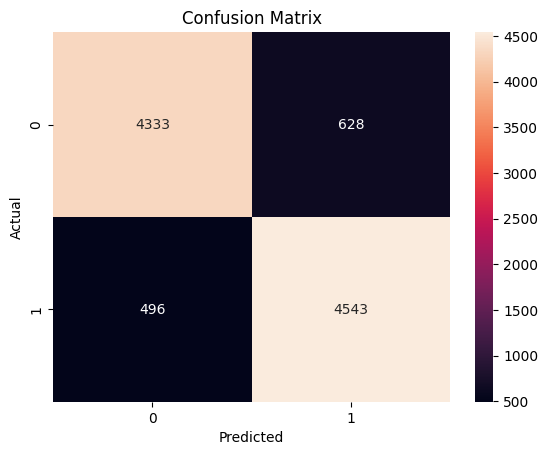

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
examples = [

    "This movie was amazing and I really enjoyed it",

    "The film was boring and a complete waste of time",

    "The acting was excellent but the story was weak"

]

In [23]:
example_features = vectorizer.transform(
    examples
)


predictions = model.predict(
    example_features
)


predictions

array([1, 0, 1])

In [24]:
for sentence, prediction in zip(examples,predictions):

    if prediction == 1:
        sentiment = "Positive"

    else:
        sentiment = "Negative"


    print("Sentence:")
    print(sentence)

    print("Prediction:",sentiment)

    print("-----------------------")

Sentence:
This movie was amazing and I really enjoyed it
Prediction: Positive
-----------------------
Sentence:
The film was boring and a complete waste of time
Prediction: Negative
-----------------------
Sentence:
The acting was excellent but the story was weak
Prediction: Positive
-----------------------


In [ ]:
# Final Summary

## Project:
Sentiment Analysis Model using IMDB Movie Reviews Dataset

## Approach:

1. Loaded the IMDB dataset containing 50,000 movie reviews.
2. Converted sentiment labels into binary format:
   - Positive = 1
   - Negative = 0
3. Cleaned text data by:
   - Converting text to lowercase
   - Removing punctuation and special characters
   - Removing stopwords
4. Converted text into numerical features using TF-IDF Vectorization.
5. Split the dataset into training and testing sets.
6. Trained a Logistic Regression classification model.
7. Evaluated performance using Accuracy, F1-score, and Confusion Matrix.
8. Tested the model on custom sentences.

## Results:

The Logistic Regression model achieved approximately 89% accuracy and F1-score on the test dataset.

## Limitation:

The model may struggle with sarcasm, complex emotions, and context-dependent sentences because it only learns patterns from words and does not fully understand language meaning.